In [ ]:
##--- IMPORT PACKAGES ---##
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [208]:
##--- DEFINE CONSTANTS AND ARRAYS ---##

# Define constants
g = 9.81          # gravitational constant
Cpd = 1004        # specific heat
Lv = 2.5e6        # latent heat of vaporization
Rd = 287          # gas constant for dry air 
Rv = 461          # gas constant for water vapor
eps = Rd / Rv     # ratio of gas constants

# Define Skew-T skewing function (provided in the assignment)
def skewT(temp, pres, skew=-20):
    return temp + skew * np.log(pres / 1000.0)

# Define temperature array
temperatures = np.arange(-100, 51, 10)

# Define pressure array for plotting
pressures = np.arange(100, 1001, 10)

# Define pressure array for calculating moist adiabats
pressures_moist = np.arange(1000, 99, -10) # Used LLM for creating pressure loop

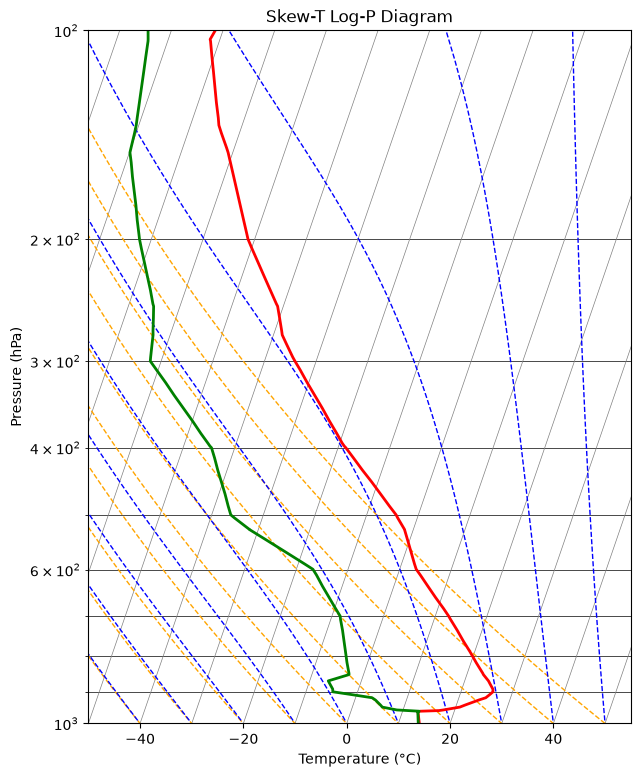

In [209]:
##--- CREATE THE SKEW-T PLOT ---##

fig, ax = plt.subplots(figsize=(7, 9))

# Pressure axis limits and scale 
ax.set_ylim(1000, 100)
ax.set_yscale('log')

# Temperature axis limits 
ax.set_xlim(-50, 55)

# Axes labels 
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Pressure (hPa)")

# Horizontal pressure linees
for pressure in [1000, 900, 800, 700, 600, 500, 400, 300, 200, 100]:
    ax.axhline(pressure, color="black", linewidth=0.5)


##--- PLOT ISOTERMS ---##

for T in temperatures:

    # Apply skew function
    x = skewT(T, pressures)

    # Plot isoterms
    ax.plot(x, pressures, color="gray", linewidth=0.5)


##--- PLOT DRY ADIABATS ---##

for T in temperatures:

    # Convert temperature from C to K
    T_K = T + 273.15

    # Calculate the dry adiabat
    dry_adiabat_K = (T_K * (pressures / 1000.0) ** (Rd / Cpd))

    # Convert back to C
    dry_adiabat_C = dry_adiabat_K - 273.15

    # Apply skew function
    x = skewT(dry_adiabat_C, pressures)

    ax.plot(x, pressures, color="orange", linewidth=1, linestyle="--")


##--- PLOT MOIST ADIABATS ---##

for T in temperatures:

    # Convert temperature from C to K
    Tk = T + 273.15

    # Define an array of new x and y axis values
    t_values = []
    p_values = []

    # Loop through pressure values in array and find the differential pressure change (dp)
    for i in range(len(pressures_moist) - 1):

        # Current and next pressure
        p = pressures_moist[i]
        p_next = pressures_moist[i + 1]

        # Pressure change
        dp = p_next - p

        # Convert temperature from K to C
        T_C = Tk - 273.15

        # Calculate the saturation vapor pressure
        Saturation_vapor_pressure = ( 6.112 * np.exp(17.67 * T_C / (T_C + 243.5)))

        # Calculate the mixing ratio
        rs = (eps * Saturation_vapor_pressure / (p - Saturation_vapor_pressure))

        # Calculate the moist adiabatic lapse rate
        moist_adiabat_lr = ((g / Cpd) * (1 + (Lv * rs) / (Rd * Tk)) / ( 1 + (Lv**2 * rs) / (Cpd * Rv * Tk**2)))

        # Convert pressure from hPa to Pa
        p_Pa = p * 100
        dp_Pa = dp * 100

        # Calculate the change in temperature 
        dT = (moist_adiabat_lr * (Rd * Tk / (g * p_Pa)) * dp_Pa)

        # Find the new temperature based on the differential temperature
        Tk = Tk + dT

        # Convert temperature from K to C
        T_C = Tk - 273.15

        # Apply Skew-T function
        x = skewT(T_C, p_next)

        # Add to x and y value arrays
        t_values.append(x)
        p_values.append(p_next)

    # Plot the moist adiabat
    ax.plot(t_values, p_values, color="blue", linewidth=1, linestyle="--")

##--- READ IN AND PLOT SOUNDING DATA ---##

# Define sounding file and read in data
sounding_file = "011026_SOUNDING.csv"
sounding_data = pd.read_csv(sounding_file)

# Read in and define sounding data arrays
sounding_temps = sounding_data["temperature_C"].values
sounding_dew = sounding_data["dew point temperature_C"].values
sounding_pres = sounding_data["pressure_hPa"].values

# Plot temperature and dewpoint by pressure
ax.plot(skewT(sounding_temps, sounding_pres), sounding_pres, color="red", linewidth=2.0)
ax.plot(skewT(sounding_dew, sounding_pres), sounding_pres, color="green", linewidth=2.0)

##--- TITLE AND SHOW THE PLOT ---##

ax.set_title("Skew-T Log-P Diagram")
plt.show()

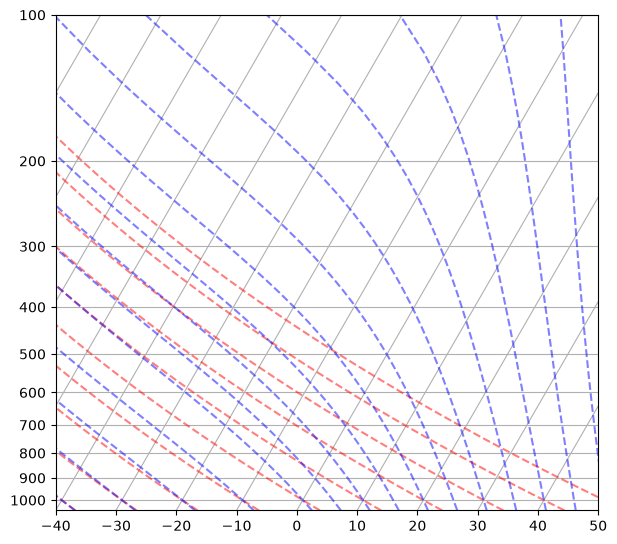

In [ ]:
##--- PROOF OF CONCEPT ---##
## This section of code is meant to demonstrate the manually created Skew-T plot matches closely 
## with the Skew-T plot created by METPY and widely accepted by 

# Define a new figure
fig = plt.figure(figsize=(7, 9))

# Create a new Skew-T plot using METPY function
skew = SkewT(fig, rotation=30)

# Add dry and moist adiabats to the SkewT plot 
skew.plot_dry_adiabats()
skew.plot_moist_adiabats()

# Show the plot
plt.show()

## Proof of Concept 1: Dry Adiabats

We can utilize Poison's Equation, because dry adiabats are lines of constant potential temperature:

$$
T = T_0 \left(\frac{p}{p_0}\right)^{R_d/c_{pd}}
$$

where

$$
R_d = 287\ \mathrm{J\,kg^{-1}\,K^{-1}}
$$

and

$$
c_{pd} = 1004\ \mathrm{J\,kg^{-1}\,K^{-1}}.
$$

I used an initial pressure of

$$
p_0 = 1000\ \mathrm{hPa}
$$

## Proof of Concept 2: Moist Adiabats

First, saturation vapor pressure needs to be calculated:

$$
e_s(T) =
6.112\exp\left[
\frac{17.67(T-273.15)}
{T-29.65}
\right],
$$

and the saturation mixing ratio,

$$
r_s =
\epsilon\frac{e_s}{p-e_s},
$$

where

$$
\epsilon = \frac{R_d}{R_v} \approx 0.622.
$$

I then calculated the moist adiabatic lapse rate using

$$
\Gamma_m =
\frac{g}{c_{pd}}
\frac{
1+\dfrac{L_v r_s}{R_dT}
}{
1+\dfrac{L_v^2r_s}{c_{pd}R_vT^2}
}.
$$

We know that

$$
\Gamma_m =
\frac{dT}{dZ}
$$

And the hydrostatic equation gives us

$$
\frac{dT}{dZ} = 
-{\rho}{g}
$$

And the ideal gas law gives us

$$
p =
{\rho}{R}{T}
$$

Solving for density in the ideal gas law equation and plugging density into the hydrostatic equation yields:

$$
\frac{dp}{dZ} =
\frac{-pg}{Rt}
$$

Plugging this into the equation for $$\Gamma_m$$ yields:

$$
\Gamma_m =
\frac{-dTpg}{dpRT}
$$

Finally, the change in temperature dT can be solved for 

$$
dT = 
\frac{\Gamma_m R T dp}{p g}
$$

Which is then added to the given temperature and can be plotted alonside the given pressure to find the moist adiabat line

## INTERPRETATION PROMPTS:

1. Why does the moist adiabatic lapse rate, Γm = −dT /dz, generally increase as a saturated parcel ascends and cools?


The moist adiabtic lapse rate increases as a saturated parcel ascends and cools because when a parcel of air is saturated, the parcels capacity to hold water vapor is reached (i.e. the saturation vapor pressure is equal to the pressure exerted by the water vapor in the parcel) and any further cooling of the parcel will result in the water vapor condensing and turning into liquid water. As the water vapor undegoes the phase change to turn from vapor to liquid, latent heat is released as the vapor is cooled. As a result of this process, moist/saturated parcels cool more slowly than dry parcels. 

However additionally, as a parcel cools when it ascends, its capacity to hold water vapor decreases and the saturation vapor pressure decreases. Given that cooler, saturated parcels hold less water vapor than moist, saturated parcels, less latent heat is released when the water vapor contained within the cooler, saturated parcels condenses. With less latent heat released than a warmer, saturated parcel, the cooling resulting from the parcels ascending and the pressure decreasing is not offset by the latent heat release due to condensation, which results in the parcel cooling off at a faster rate (i.e. an increased moist adiabatic lapse rate).

2. At a fixed pressure, how and why does Γm differ between warmer and colder moist adiabats?

Γm at a fixed pressure differs between the warmer and cooler adiabats because a warmer, saturated parcel holds more water vapor than a cooler saturated parcel (warm area can hold more water than cold air). Therefore, when a warmer parcel becomes saturated, the latent heat which is released when the water vapor in the parcel condense is much greater than it would be in a cooler parcel, simply because there is more water vapor. Therefore, the moist adiabatic lapse rate for a warmer parcel would be much less than a cool parcel, because the rate of cooling is offset by the added heat from the latent heat release from condensation. More latent heat is released with a warmer parcel, which means the rate of cooling is offset more. 

3. Break” your SkewT: test a wide range of skew values and describe what happens to the plot. What
does this test teach you about the value of skewing? No need to show your tests; just describe your
interpretations.

After testing a range of values which are greater and less than the initial skew value of -20, it shows that skew values drastically changes how much the moist and the dry adiabts decreases or increase with height. When the skew values is decreased, the adiabats actually appear to skew toward the right and increase rapidly with height, and the plotted sounding data also is given the appearence that both the temperature and dewpoint are increasing with height drastically. However, when the value is increased, the adiabats are slanted drastically to the left and decrease rapidly with height. When a skew value of zero is tested, the adiabts are still slanted toward the left, and the sounding data appears to get cut off toward the middle of the atmosphere. Testing the skew values shows the importance of skewing the plot in order to represent all of the values accurately in a two dimensional plot. If the skew was not put in place, the physically constraints of a skew-t plot would not be able to capture the change in temperature over the entire atmosphere, as when no skewing was put in place the sounding data appeared to be cut off. However, it is important to pick your value of skewing carefully, because over-skewing the data can be just as misleading as not skewing the data at all. 

4. Describe two features of the sounding you chose to plot that you find particularly interesting or useful. Refer to specific pressure levels or layers and explain the physical significance of each feature.

One interesting aspect of my chosen sounding is the layer between 1000 hPa and 950 hPa. The sounding temperature and dewpoint are equal to each other in this layer, indicating that the atmosphere is completely saturated. When there is a completely saturated shallow layer such as this on a sounding, this indicated stratiform rain at the surface. 

Another interesting aspect of my chosen sounding is the steep temperature inversion that is present between 950 hPa and 900 hPa. This steep inversion is created when temperature increase with height, and indicated a very stable atmosphere. 

5. What was the most challenging step for this lab? How did you navigate it, and what was the solution? If you leaned on GenAI tools, how did they contribute to your work and how did you check the information they provided?



Initially, the most challenging aspect of this lab was conceptualizing and understanding what the moist and dry adiabats represented, and how to find an equation to calculate the adiabats that were to be plotted. Once equations for the moist and dry adiabts were found, creating the Skew-T diagram was overall straight-forward. The only portion of this assignment in which I utilized GenAI was in the creation of the pressure loop that was utilized to find the moist adiabats. I used GenAI to help give me the proper values to iterate through and to optimize the best way to calculate and store the values of temperature and pressure before being plotted on the Skew-T. I also used GenAI to debug my moist adiabats when I ran into issues with converting values of pressure and temperature between Kelvin/Celcius and Pascals/Hectopascals. I also utilized GenAI when creating the markdown cells for my "proof of concept" because I am not experienced writing with LaTeX.